In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt


In [3]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.top": False,
    "ytick.right": False,
    
    "axes.grid": True,
    "grid.color": "#7F8C8D",
    "grid.linestyle": ":",       
    "grid.alpha": 0.5,
    
    "legend.frameon": True,
    
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight"
})

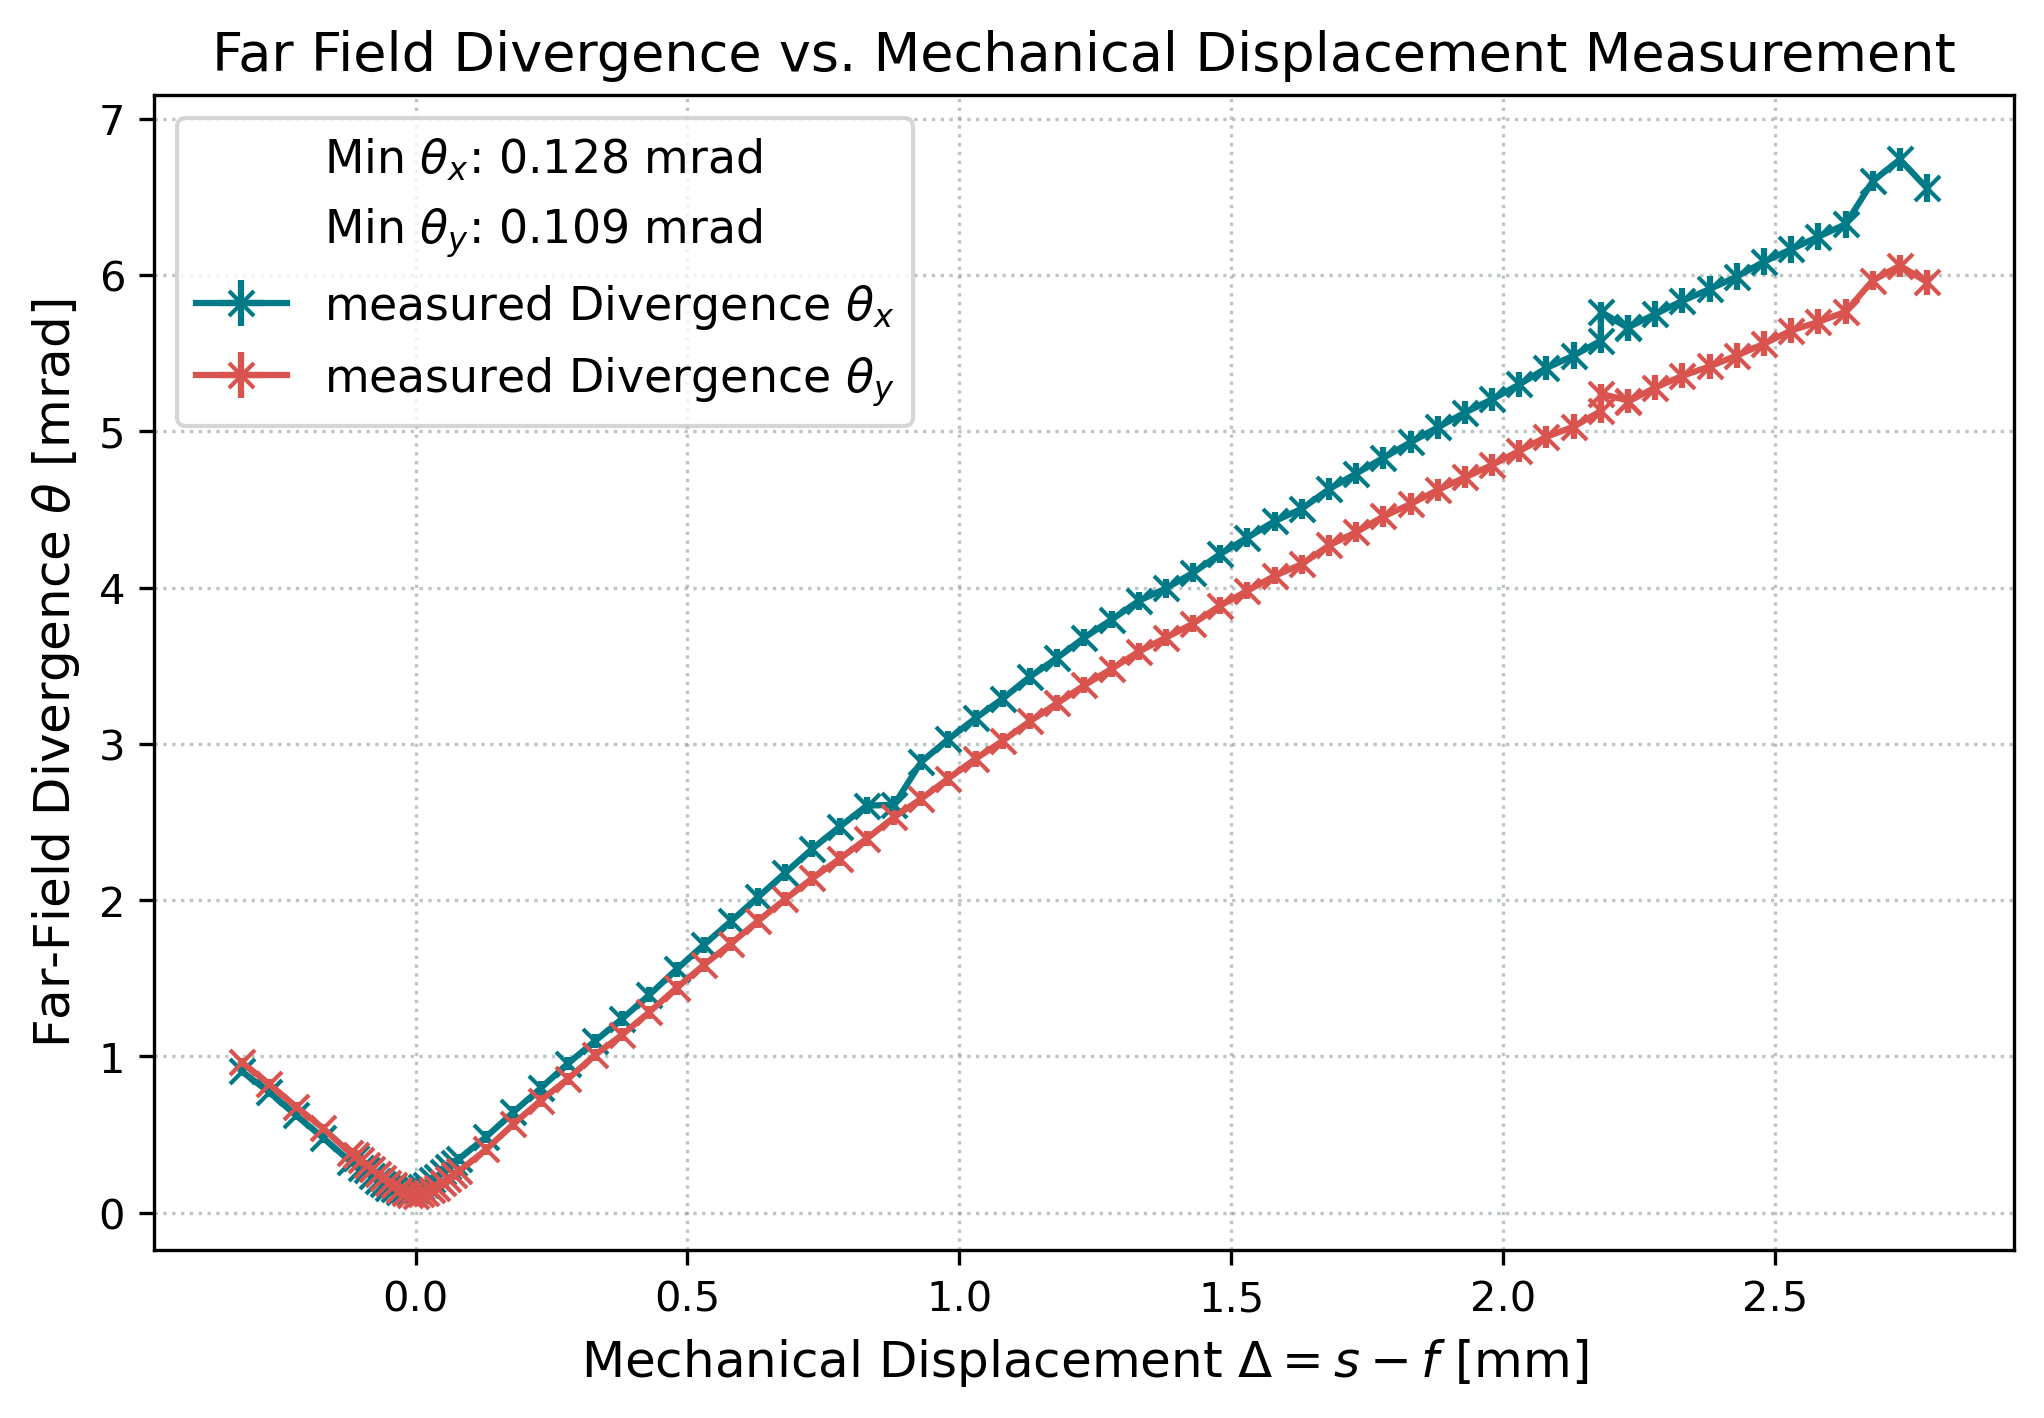

In [4]:
#mit fehler
#übersicht:
data = np.genfromtxt(
    '/Users/trinity/Desktop/bachelor.thesis/measurements/set_up_messung/m2_measurements_1308_2.csv',
    delimiter=','
)

lam  = 1064e-9   # Wavelength [m]
MFD  = 5.4e-6    # Mode Field Diameter [m]
w0   = MFD / 2   # Waist radius at the fiber end [m]
f    = 36.6e-3  

distance_mechanical = data[:, 0]
delta= distance_mechanical - 4.32
theta_x_full = data[:, 1] #theta mesured is full angle
theta_x_full_error = data[:, 2]

M2_x = data[:, 3]
M2_x_error = data[:, 4]

theta_y_full = data[:, 5]
theta_y_full_error = data[:, 6]
M2_y = data[:, 7]
M2_y_error = data[:, 8]


theta_x_half = theta_x_full / 2
theta_y_half = theta_y_full / 2
theta_x_half_error = theta_x_full_error / 2
theta_y_half_error = theta_y_full_error / 2

zR_x = data[:, 9]

delta_error=0.005


def theta(M2, delta):
    zR_fiber = (np.pi * w0**2) / lam*M2
    return M2*lam/(np.pi*w0*f) *np.sqrt(delta**2 + zR_fiber**2)

min_theta_x = np.nanmin(theta_x_half)
min_theta_y = np.nanmin(theta_y_half)

plt.figure(figsize=(8, 5))
plt.errorbar(delta, theta_x_half, xerr=delta_error, yerr=theta_x_half_error, fmt='-x', color='#007A87', label=r'measured Divergence $\theta_x$')
plt.errorbar(delta, theta_y_half, xerr=delta_error, yerr=theta_y_half_error, fmt='-x', color='#D9534F', label=r'measured Divergence $\theta_y$')

plt.plot([], [], ' ', label=rf'Min $\theta_x$: {min_theta_x:.3f} mrad')
plt.plot([], [], ' ', label=rf'Min $\theta_y$: {min_theta_y:.3f} mrad')

plt.xlabel(rf"Mechanical Displacement $\Delta = s - f$ [mm]")
plt.ylabel(rf"Far-Field Divergence $\theta$ [mrad]")
plt.title(rf'Far Field Divergence vs. Mechanical Displacement Measurement')
plt.legend(loc='upper left')
plt.savefig("/Users/trinity/Desktop/bachelor.thesis/ba_plots/measurements/setup/divergence_vs_mechanival_displacement_full_errors.pdf")

plt.show()


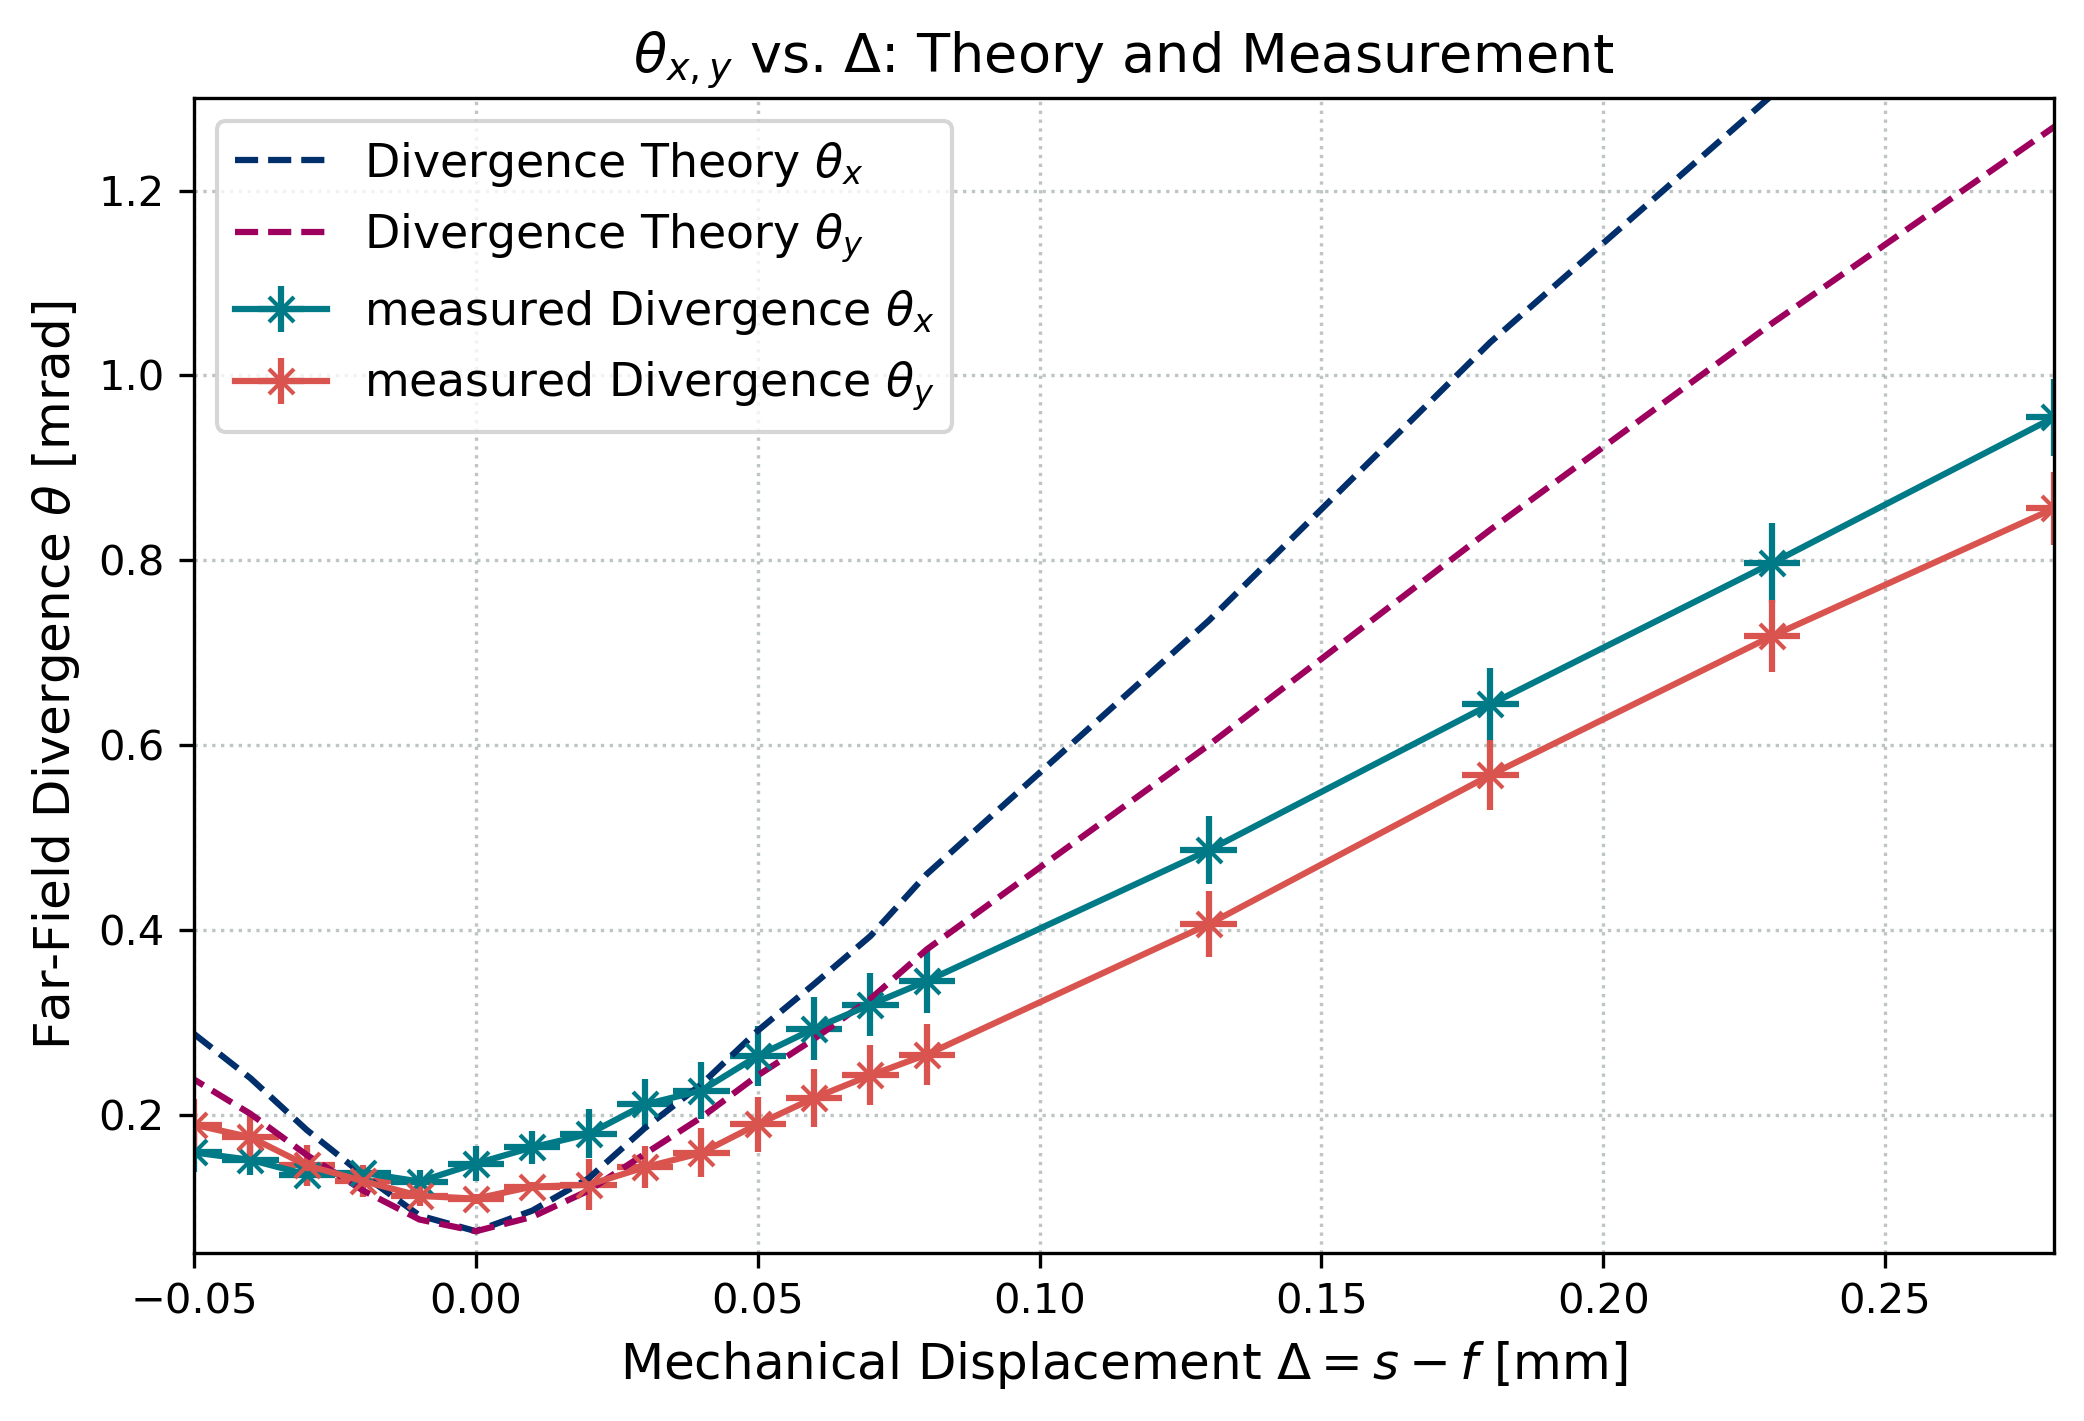

In [5]:
#theroie vs measurment +error

data = np.genfromtxt(
    '/Users/trinity/Desktop/bachelor.thesis/measurements/set_up_messung/m2_measurements_1308_2.csv',
    delimiter=','
)

lam  = 1064e-9   # Wavelength [m]
MFD  = 5.4e-6    # Mode Field Diameter [m]
w0   = MFD / 2   # Waist radius at the fiber end [m]
f    = 36.6e-3  

distance_mechanical = data[:, 0]
delta= distance_mechanical - 4.32
theta_x_full = data[:, 1] #theta mesured is full angle
theta_x_full_error = data[:, 2]

M2_x = data[:, 3]
M2_x_error = data[:, 4]

theta_y_full = data[:, 5]
theta_y_full_error = data[:, 6]
M2_y = data[:, 7]
M2_y_error = data[:, 8]


theta_x_half = theta_x_full / 2
theta_y_half = theta_y_full / 2
theta_x_half_error = theta_x_full_error / 2
theta_y_half_error = theta_y_full_error / 2


zR_x = data[:, 9]

delta_error=0.005

def theta_theory(M2, delta_mm): #HALF DIVERGENCE

    delta_m = delta_mm * 1e-3 
    zR_fiber = (np.pi * w0**2) / (lam * M2)
    return (M2 * lam / (np.pi * w0 * f) * np.sqrt(delta_m**2 + zR_fiber**2)) * 1000

plt.figure(figsize=(8, 5))
plt.errorbar(delta, theta_x_half, xerr=delta_error, yerr=theta_x_half_error, fmt='-x', color='#007A87', label=r'measured Divergence $\theta_x$')
plt.errorbar(delta, theta_y_half, xerr=delta_error, yerr=theta_y_half_error, fmt='-x', color='#D9534F', label=r'measured Divergence $\theta_y$')

plt.plot(delta, theta_theory(M2_x, delta), '--', color='#002F6C', label=r'Divergence Theory $\theta_x$')
plt.plot(delta, theta_theory(M2_y, delta), '--', color='#9E005D', label=r'Divergence Theory $\theta_y$')

plt.xlabel(rf"Mechanical Displacement $\Delta = s - f$ [mm]")
plt.ylabel(rf"Far-Field Divergence $\theta$ [mrad]")
plt.xlim(-0.05, 0.28)
plt.ylim(0.05, 1.3)
plt.title(rf'$\theta_{{x,y}}$ vs. $\Delta$: Theory and Measurement')
plt.legend(loc='upper left')
plt.savefig("/Users/trinity/Desktop/bachelor.thesis/ba_plots/measurements/setup/divergence_vs_mechanival_displacement_theory_errors.pdf")
plt.show()

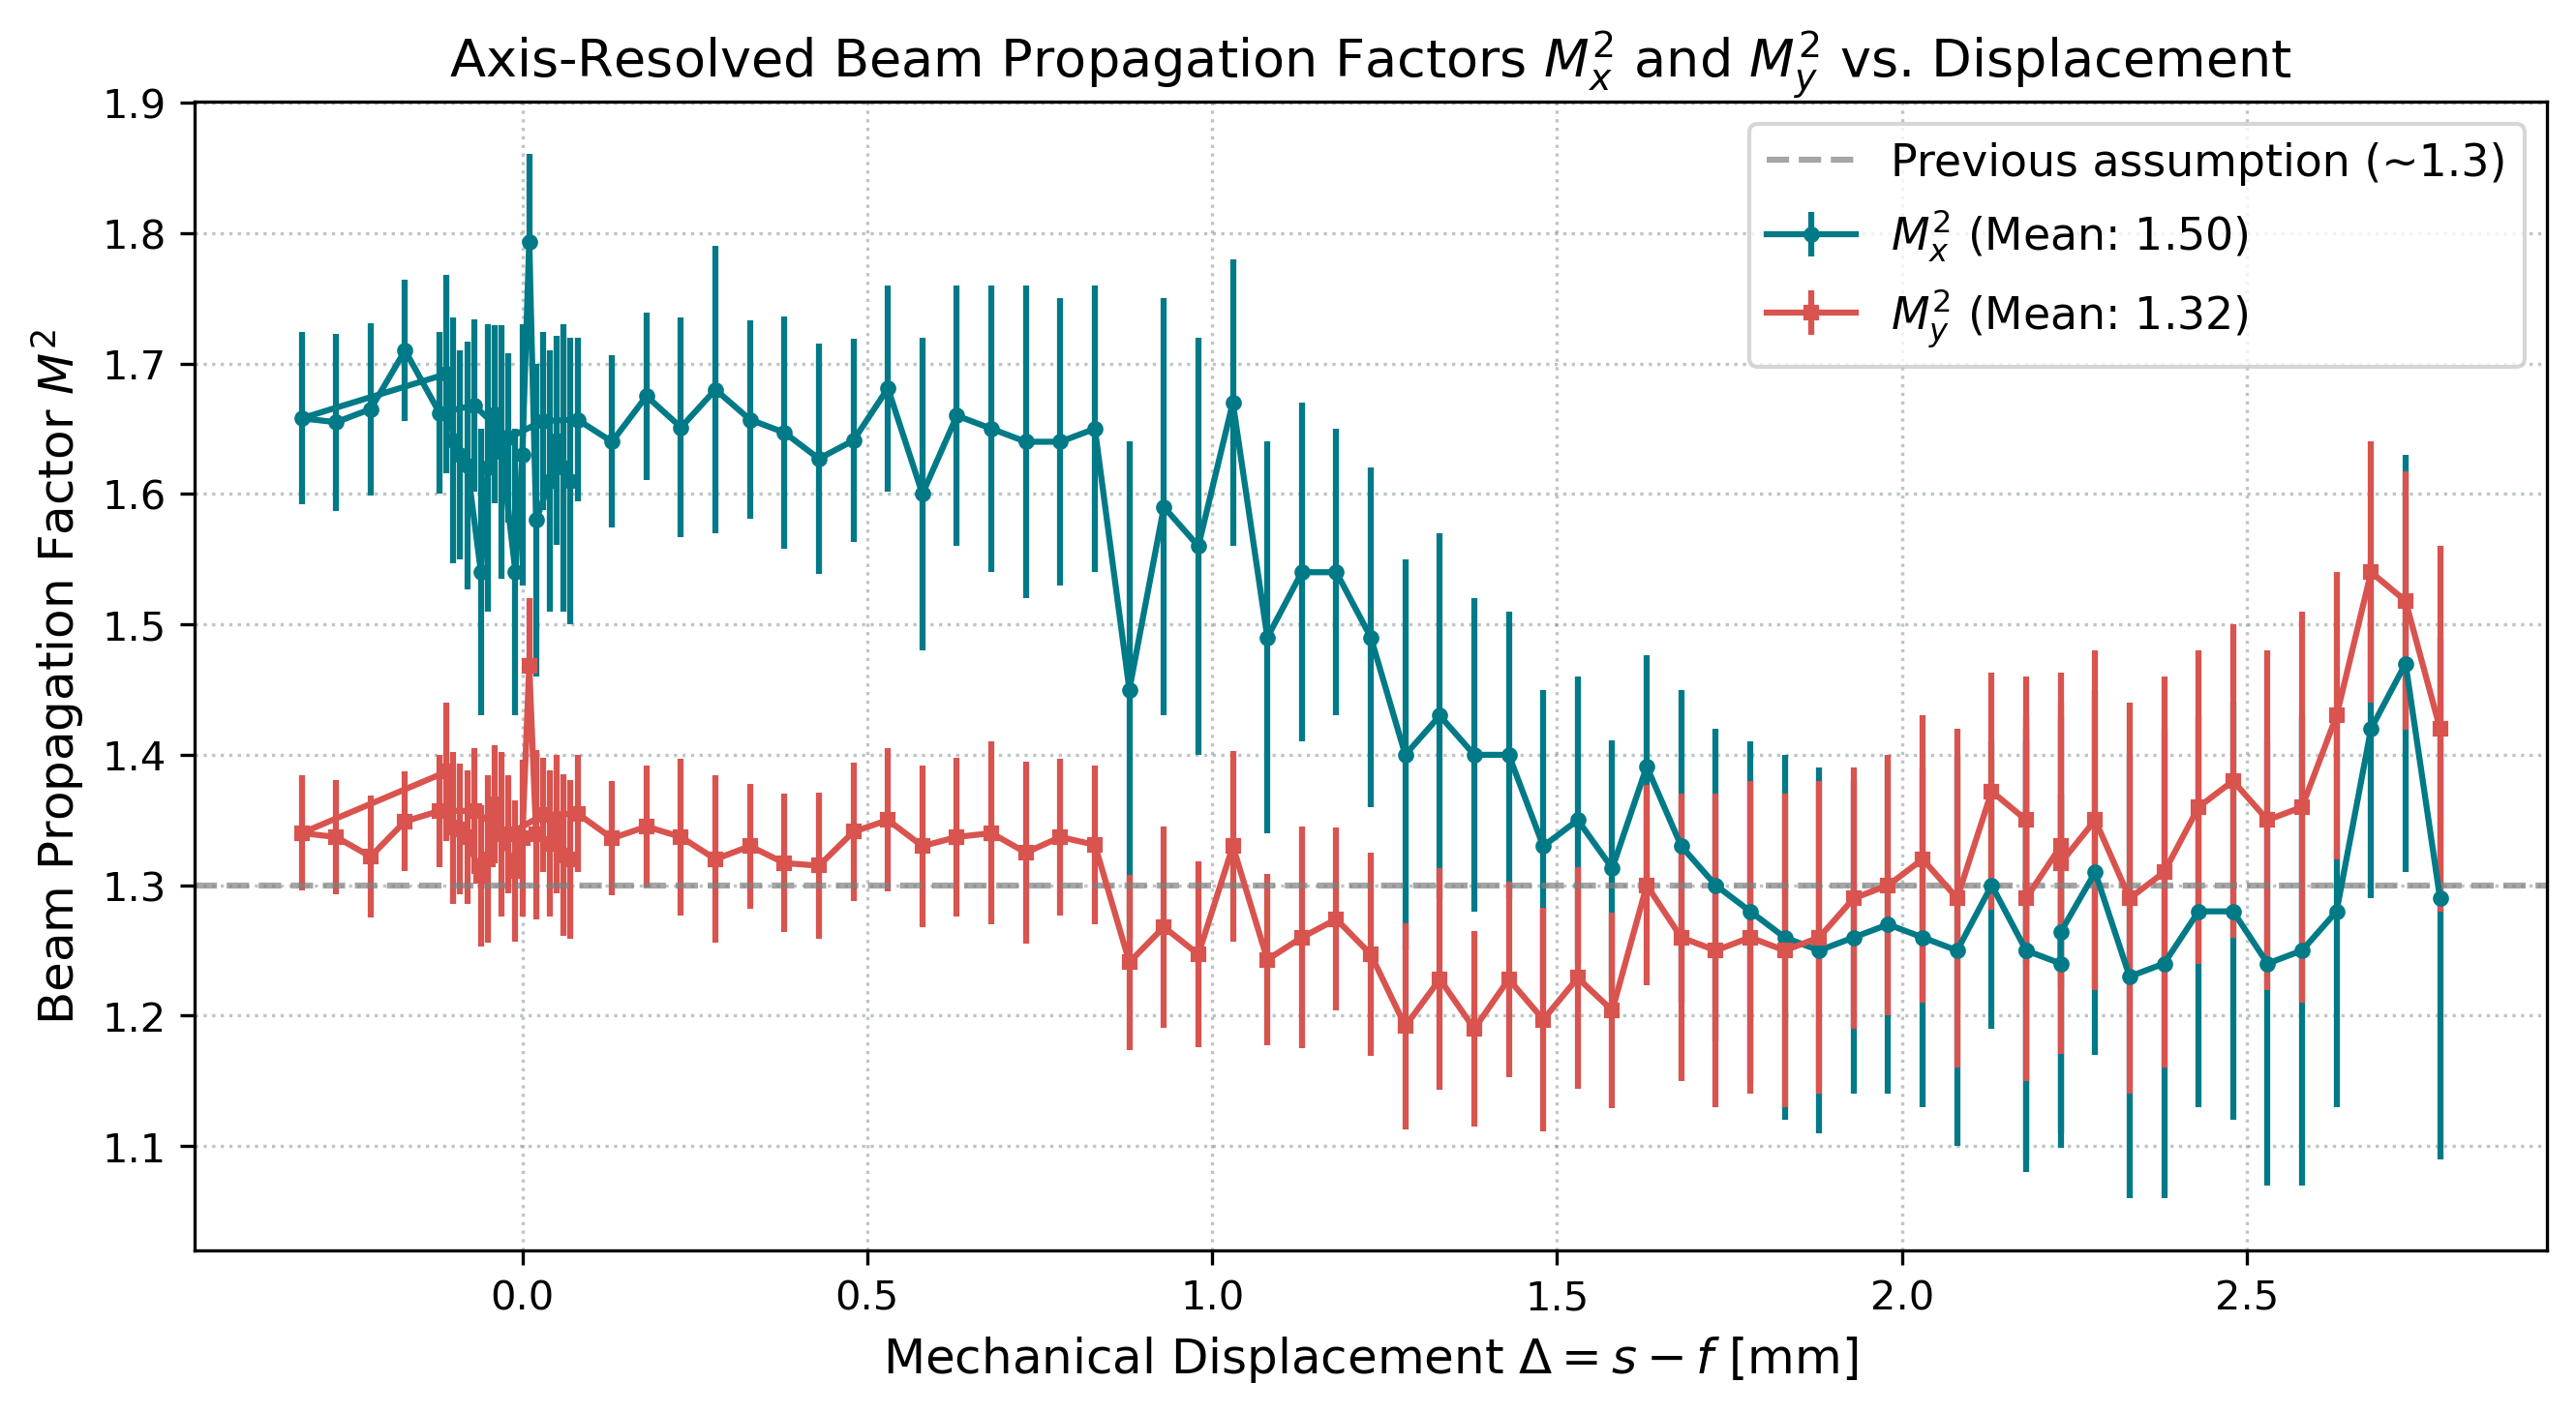

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

neuer_pfad = "/Users/trinity/Desktop/bachelor.thesis/measurements/set_up_messung"

os.chdir(neuer_pfad)

# CSV-Datei einlesen (angepasst an deinen Datensatz)
df = pd.read_csv('m2_measurements_1308_2.csv', header=None)
sub_df = df.iloc[3:, 12:22].copy()
sub_df.columns = ['distanz', 'theta_x', 'theta_x_err', 'm2_x', 'm2_x_err', 'theta_y', 'theta_y_err', 'm2_y', 'm2_y_err', 'zR_x']
sub_df = sub_df.dropna(subset=['distanz'])

for col in sub_df.columns:
    sub_df[col] = pd.to_numeric(sub_df[col], errors='coerce')
sub_df = sub_df.dropna()

distanz = sub_df['distanz']
m2_x = sub_df['m2_x']
m2_x_err = sub_df['m2_x_err']
m2_y = sub_df['m2_y']
m2_y_err = sub_df['m2_y_err']
delta= distanz - 4.32

# Statistische Mittelwerte berechnen
mean_x = np.mean(m2_x)
mean_y = np.mean(m2_y)

# Plot erstellen
plt.figure(figsize=(9, 5))
plt.errorbar(delta, m2_x, yerr=m2_x_err, fmt='-o', markersize=3, color='#007A87', label=r'$M^2_x$ (Mean: %.2f)' % mean_x)
plt.errorbar(delta, m2_y, yerr=m2_y_err, fmt='-s', markersize=3, color='#D9534F', label=r'$M^2_y$ (Mean: %.2f)' % mean_y)

# Vergleichslinie zur alten Annahme
plt.axhline(1.3, color='gray', linestyle='--', alpha=0.7, label='Previous assumption (~1.3)')

plt.xlabel(rf"Mechanical Displacement $\Delta = s - f$ [mm]")
plt.ylabel(r"Beam Propagation Factor $M^2$")
plt.title(r"Axis-Resolved Beam Propagation Factors $M^2_x$ and $M^2_y$ vs. Displacement")
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()

plt.savefig("/Users/trinity/Desktop/bachelor.thesis/ba_plots/measurements/setup/m2_vs_displacement_stat.pdf")
plt.show()

In [7]:
#m2 plot
'''data = np.genfromtxt(
    '/Users/trinity/Desktop/bachelor.thesis/measurements/1308_1408_measure/m2_measurements_1308.csv',
    delimiter=','
)

distance_mechanical = data[:, 0]
delta= distance_mechanical - 4.315
theta_u = data[:, 1]
M2_u = data[:, 2]
theta_v = data[:, 4]
M2_v = data[:, 5]


plt.figure(figsize=(8, 5))
plt.plot(delta, M2_u, '-x',label='M2_u (Breite)', color='#007A87')
plt.plot(delta, M2_v, '-x', label='M2_v (Höhe)', color='#D9534F')

plt.xlabel(r"Mechanical Displacement delta=s-f [mm]")
plt.ylabel('M2')
plt.title('M2 vs. Mechanical Displacement (F810APC)')
plt.legend()
plt.savefig("/Users/trinity/Desktop/bachelor.thesis/ba_plots/measurements/setup/M2_vs_mechanival_displacement.pdf")


plt.show()
#theta= M2 wave/ w*pi'''

'data = np.genfromtxt(\n    \'/Users/trinity/Desktop/bachelor.thesis/measurements/1308_1408_measure/m2_measurements_1308.csv\',\n    delimiter=\',\'\n)\n\ndistance_mechanical = data[:, 0]\ndelta= distance_mechanical - 4.315\ntheta_u = data[:, 1]\nM2_u = data[:, 2]\ntheta_v = data[:, 4]\nM2_v = data[:, 5]\n\n\nplt.figure(figsize=(8, 5))\nplt.plot(delta, M2_u, \'-x\',label=\'M2_u (Breite)\', color=\'#007A87\')\nplt.plot(delta, M2_v, \'-x\', label=\'M2_v (Höhe)\', color=\'#D9534F\')\n\nplt.xlabel(r"Mechanical Displacement delta=s-f [mm]")\nplt.ylabel(\'M2\')\nplt.title(\'M2 vs. Mechanical Displacement (F810APC)\')\nplt.legend()\nplt.savefig("/Users/trinity/Desktop/bachelor.thesis/ba_plots/measurements/setup/M2_vs_mechanival_displacement.pdf")\n\n\nplt.show()\n#theta= M2 wave/ w*pi'

In [8]:
'''not worth in the end
data = np.genfromtxt(
    '/Users/trinity/Desktop/bachelor.thesis/measurements/1308_1408_measure/m2_measurements_1308.csv',
    delimiter=','
)

lam  = 1064e-9   
MFD  = 5.4e-6    
w0   = MFD / 2   
f    = 36.6e-3  

distance_mechanical = data[:, 0]
delta_mm = distance_mechanical - 4.315
delta_m  = delta_mm * 1e-3 

theta_u = data[:, 1]
M2_u    = data[:, 2]
zR_u    = data[:, 3]
theta_v = data[:, 4]
M2_v    = data[:, 5]
zR_v    = data[:, 6]


def zR_theory(delta_meters, M2_val):
    lam_eff = lam * M2_val
    zR_fiber = (np.pi * w0**2) / lam_eff 
    
    zR_new_meters = (f**2 * zR_fiber) / (delta_meters**2 + zR_fiber**2)
    
    return zR_new_meters * 1000


plt.figure(figsize=(8, 5))


plt.plot(delta_mm, zR_u, '-x', label=r'Measurement $z_R$ (Width)', color='#007A87')
plt.plot(delta_mm, zR_v, '-x', label=r'Measurement $z_R$ (Height)', color='#D9534F')


plt.plot(delta_mm, zR_theory(delta_m, M2_u), '--', label=r'Theory $z_{R,u}$', color='blue', alpha=0.5)
plt.plot(delta_mm, zR_theory(delta_m, M2_v), '--', label=r'Theory $z_{R,v}$', color='red',alpha=0.5)

plt.xlabel(r"Mechanical Displacement $\Delta = s - f$ [mm]")
plt.ylabel(r"Far-Field Rayleigh Range $z_{R,\text{new}}$ [mm]")
plt.title('Far-Field Rayleigh Range vs. Mechanical Displacement') # Titel angepasst!
plt.legend()

plt.tight_layout()
# plt.savefig("/Users/trinity/Desktop/bachelor.thesis/ba_plots/measurements/setup/rayleigh_vs_mechanical_displacement.pdf")
plt.show()'''

'not worth in the end\ndata = np.genfromtxt(\n    \'/Users/trinity/Desktop/bachelor.thesis/measurements/1308_1408_measure/m2_measurements_1308.csv\',\n    delimiter=\',\'\n)\n\nlam  = 1064e-9   \nMFD  = 5.4e-6    \nw0   = MFD / 2   \nf    = 36.6e-3  \n\ndistance_mechanical = data[:, 0]\ndelta_mm = distance_mechanical - 4.315\ndelta_m  = delta_mm * 1e-3 \n\ntheta_u = data[:, 1]\nM2_u    = data[:, 2]\nzR_u    = data[:, 3]\ntheta_v = data[:, 4]\nM2_v    = data[:, 5]\nzR_v    = data[:, 6]\n\n\ndef zR_theory(delta_meters, M2_val):\n    lam_eff = lam * M2_val\n    zR_fiber = (np.pi * w0**2) / lam_eff \n    \n    zR_new_meters = (f**2 * zR_fiber) / (delta_meters**2 + zR_fiber**2)\n    \n    return zR_new_meters * 1000\n\n\nplt.figure(figsize=(8, 5))\n\n\nplt.plot(delta_mm, zR_u, \'-x\', label=r\'Measurement $z_R$ (Width)\', color=\'#007A87\')\nplt.plot(delta_mm, zR_v, \'-x\', label=r\'Measurement $z_R$ (Height)\', color=\'#D9534F\')\n\n\nplt.plot(delta_mm, zR_theory(delta_m, M2_u), \'--\', la